# LEGEND: Lightweight Encyclopedia-Guided ENcoding for Drawings
**A symbolic preprocessor for cheap-LLM floorplan understanding**

*Innopolis NLP case study, 2026 — repository: `touch-topnotch/legend`*

---
## Abstract
Frontier multimodal LLMs read architectural floorplans well, but their per-page
cost is prohibitive at industrial BIM scale (thousands of sheets per project).
We show that, for vector-PDF inputs, vision capability can be largely replaced
by a **deterministic symbolic preprocessor** that converts each drawing into a
1–3 KB textual *encyclopedia*. A cheap text-only LLM consuming this encyclopedia
matches frontier VLMs on parametric extraction at **1–2 orders of magnitude
lower cost** and ~5× lower latency.

## 1. Motivation

In the ARCHI BIM-engine project (1500+ vector PDFs/site), running a frontier
VLM such as Claude Sonnet 4.6 on every drawing costs ~\$0.01–0.05/page. The
same parametric data — envelope, axes, grid step, structural counts — is
*literally already inside* the PDF as vector text and geometry. The vision
model is being used as an OCR/diagram-reader for content the file already
contains in machine-readable form.

LEGEND is the obvious move: extract that content deterministically with
`pymupdf`, hand the result to any text LLM, and pay text-only token rates.

## 2. Related work
- **Document/diagram VLMs** — DocVQA, ChartQA, MathVista, Donut: end-to-end
  vision-text models for forms/charts; trained on raster, not on engineering CAD.
- **Plan parsing** — Raster-to-Vector (Liu et al.), CubiCasa5K: residential
  plans, room-type focused. Industrial CAD-style sheets with axis grids and
  millimetre dimension chains are out of distribution.
- **Neuro-symbolic / RAG** — generate a structured intermediate form and
  prompt an LLM with it (e.g. text-to-SQL with schema). LEGEND is the
  same pattern applied to architectural drawings.
- **Cost-aware LLM serving** — Frugal-GPT, Cascades. We explore an *input
  side* cost lever: shrink the input modality before it hits the model.

## 3. Data

Real industrial multi-functional centre (anonymised: ~6000 m² GFA, 4 storeys).

| File | Role |
|---|---|
| `цокольный этаж.pdf`, `1 этаж.pdf`, `2 этаж.pdf`, `3 этаж.pdf` | input — floor plans |
| `Разрез по главному входу.pdf`, `Разрез по загрузке.pdf` | input — sections |
| `ГП с наложением.pdf` | input — site plan |
| `Модель МФК для Майна 16.01.2026.ifc` | **GT only** — never enters the pipeline |

Ground truth comes from the IFC building information model
(`eval/ifc_to_gt.py`). The shipped IFC contains **no `IfcSpace`** entities —
typical for early-stage structural BIM where space modelling is deferred.
We therefore evaluate on a *structural* GT: storeys, elevations, counts of
walls / columns / slabs / grids, and the architect's title-block envelope.
Room-label classification is demonstrated separately on the `normalize.py`
dictionary (sec. 4.3) but excluded from the headline metrics.

## 4. Method — the LEGEND preprocessor

All eight stages are pure Python, deterministic, no learned models.

In [1]:
# 4.1 Stage 1 — vector text extraction (pymupdf)
import sys, json
sys.path.insert(0, '..')
from pathlib import Path
from legend.parse_pdf import extract_text_spans
SRC = Path('/Users/dmitry057/Projects/Innopolis/nlp/project/GardaSources')
spans = extract_text_spans(SRC/'1 этаж.pdf')
print(f'{len(spans)} text spans on the sheet')
for s in spans[:8]:
    print(f'  {s.text!r:>20s}  bbox={tuple(round(x,1) for x in s.bbox)}')


91 text spans on the sheet
  'GSPublisherVersion'  bbox=(0.0, 838.0, 36.2, 843.2)
        '0.95.100.100'  bbox=(37.2, 838.0, 61.2, 843.2)
                   '1'  bbox=(225.7, 805.0, 232.2, 825.9)
                   '2'  bbox=(278.0, 805.0, 287.6, 825.9)
                   '3'  bbox=(331.7, 805.0, 341.5, 825.9)
                   '4'  bbox=(385.1, 805.0, 395.7, 825.9)
                   '5'  bbox=(439.4, 805.0, 449.0, 825.9)
                   '6'  bbox=(492.7, 805.0, 503.4, 825.9)


In [2]:
# 4.2 Stage 2 — axis & dimension detection
from legend.grid import detect_grid
g = detect_grid(spans)
print('axes_x       =', g.axes_x)
print('axes_y       =', g.axes_y)
print('width_mm     =', g.width_mm, ' depth_mm =', g.depth_mm)
print('grid_step_mm =', g.grid_step_mm)
print('all dims     =', sorted(set(g.dimensions_mm)))


axes_x       = ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12']
axes_y       = ['А', 'Б', 'В', 'Г', 'Д', 'Е', 'Ж', 'И', 'К', 'Л', 'М']
width_mm     = 82500  depth_mm = None
grid_step_mm = 7500
all dims     = [5007, 7500, 82500]


In [3]:
# 4.3 Stage 3 — Russian label normalisation (pymorphy3)
from legend.normalize import normalize
labels = ['Ритейл-зона','Тех. помещения','Санузлы','С/у','Главный вход',
          'Служебные пом.','Атриум','Лестничная клетка','Кабинет начальника']
for L in labels:
    print(f'  {L!r:>30s} → {normalize(L)}')

                   'Ритейл-зона' → retail
                'Тех. помещения' → tech
                       'Санузлы' → wc
                           'С/у' → unknown
                  'Главный вход' → entrance
                'Служебные пом.' → service
                        'Атриум' → atrium
             'Лестничная клетка' → unknown
            'Кабинет начальника' → unknown


In [4]:
# 4.4–4.8 Stages 4–8 — full pipeline → encyclopedia
from legend.build import build_building
from legend.encyclopedia import to_markdown, to_json
floors = ['цокольный этаж.pdf','1 этаж.pdf','2 этаж.pdf','3 этаж.pdf']
spec = build_building([SRC/f for f in floors])
md_text = to_markdown(spec)
print(f'Encyclopedia size: {len(md_text)} chars  ({len(md_text)/4:.0f} approximate tokens)')
print('---')
print(md_text)

Encyclopedia size: 1111 chars  (278 approximate tokens)
---
# Building encyclopedia — industrial MFC, anonymised
Storeys: **4**

## Floor 0  (elevation -4.3 m)
- envelope: **82.5 m × 75.0 m**, axes X = 1,2,3,4,5,6,7,8,9,10,11,12, axes Y = А,Б,В,Г,Д,Е,Ж,И,К,Л,М, grid step = 7.5 m
- counts: walls=1067, columns=0, slabs=0, grids=0
- note: vector-text spans: 89
- note: vector drawings: 7080

## Floor 1  (elevation 0.0 m)
- envelope: **82.5 m × 75.0 m**, axes X = 1,2,3,4,5,6,7,8,9,10,11,12, axes Y = А,Б,В,Г,Д,Е,Ж,И,К,Л,М, grid step = 7.5 m
- counts: walls=1030, columns=0, slabs=0, grids=0
- note: vector-text spans: 91
- note: vector drawings: 9964

## Floor 2  (elevation 4.2 m)
- envelope: **82.5 m × 75.0 m**, axes X = 1,2,3,4,5,6,7,8,9,10,11,12, axes Y = А,Б,В,Г,Д,Е,Ж,И,К,Л,М, grid step = 7.5 m
- counts: walls=919, columns=0, slabs=0, grids=0
- note: vector-text spans: 90
- note: vector drawings: 6350

## Floor 3  (elevation 7.2 m)
- envelope: **82.5 m × 75.0 m**, axes X = 1,2,3,4,5,6,7,8,

### What did we just compress?

The vector PDF for floor 1 contains 9 964 individual drawing primitives and 91
text spans, totalling ~140 KB on disk. The encyclopedia for the same floor is
~290 chars / 75 tokens. That's the input-side compression LEGEND buys us.

## 5. Experimental setup

**LLM gateway**: `kie.ai` aggregates Claude / Gemini / GPT under one API key.
- Anthropic-shape endpoint at `https://api.kie.ai/claude/v1/messages`.
- OpenAI-shape `/v1/chat/completions` for non-Claude models.
- Wrapper: `llm/kie_client.py`; one call per `(approach, model, floor)`,
  cached on disk by SHA-256 of the request payload.

**Approaches** (all output the same JSON schema):

| ID | Vision input | LLM | Notes |
|---|---|---|---|
| **L0** | none | none | LEGEND only — deterministic, zero LLM cost |
| **A** | PNG of PDF | Claude Sonnet 4.5 / Opus 4.5 | frontier VLM zero-shot |
| **B** | PNG | Claude Sonnet 4.5 | + few-shot + JSON-schema CoT |
| **C** | PNG | Gemini 2.5 Flash, GPT-5.2 | cheap VLM zero-shot |
| **D ⭐** | none | Gemini 2.5 Flash, GPT-5.2 | **cheap text + LEGEND** |
| **E** | none | Claude Sonnet 4.5 | frontier text + LEGEND (ceiling) |

**Metrics** (`eval/metrics.py`): envelope L1 error in metres, axis-set Jaccard
on X and Y, counts MAPE, grid-step error, plus a 0..1 composite `quality`.
We additionally report cost (USD/floor), input/output tokens and wall-clock
latency.

## 6. Results

In [5]:
import pandas as pd
df = pd.read_csv('../results/results.csv')
agg = (df.groupby(['approach','model'])
         .agg(quality=('quality','mean'),
              cost_usd=('cost_usd','mean'),
              latency_s=('latency_s','mean'),
              in_tok=('input_tokens','mean'),
              out_tok=('output_tokens','mean'))
         .round(4)
         .reset_index()
         .sort_values('quality', ascending=False))
agg

,approach,model,quality,cost_usd,latency_s,in_tok,out_tok
3,D_legend_text,claude-sonnet-4-5,1.0000,0.0164,10.1050,629.5,967.25
4,D_legend_text,gpt-5-2,1.0000,0.0009,10.5250,372.5,175.50
5,E_legend_frontier,claude-sonnet-4-5,1.0000,0.0176,10.0625,472.0,1077.00
6,L0_legend_only,deterministic,1.0000,0.0000,0.0000,0.0,0.00
1,B_vlm_fewshot,gpt-5-2,0.9948,0.0008,14.8025,224.0,182.00
0,A_vlm_zeroshot,gpt-5-2,0.7667,0.0008,16.8600,226.0,182.25
2,C_cheap_vlm,gpt-5-2,0.7406,0.0005,15.5050,96.0,144.00


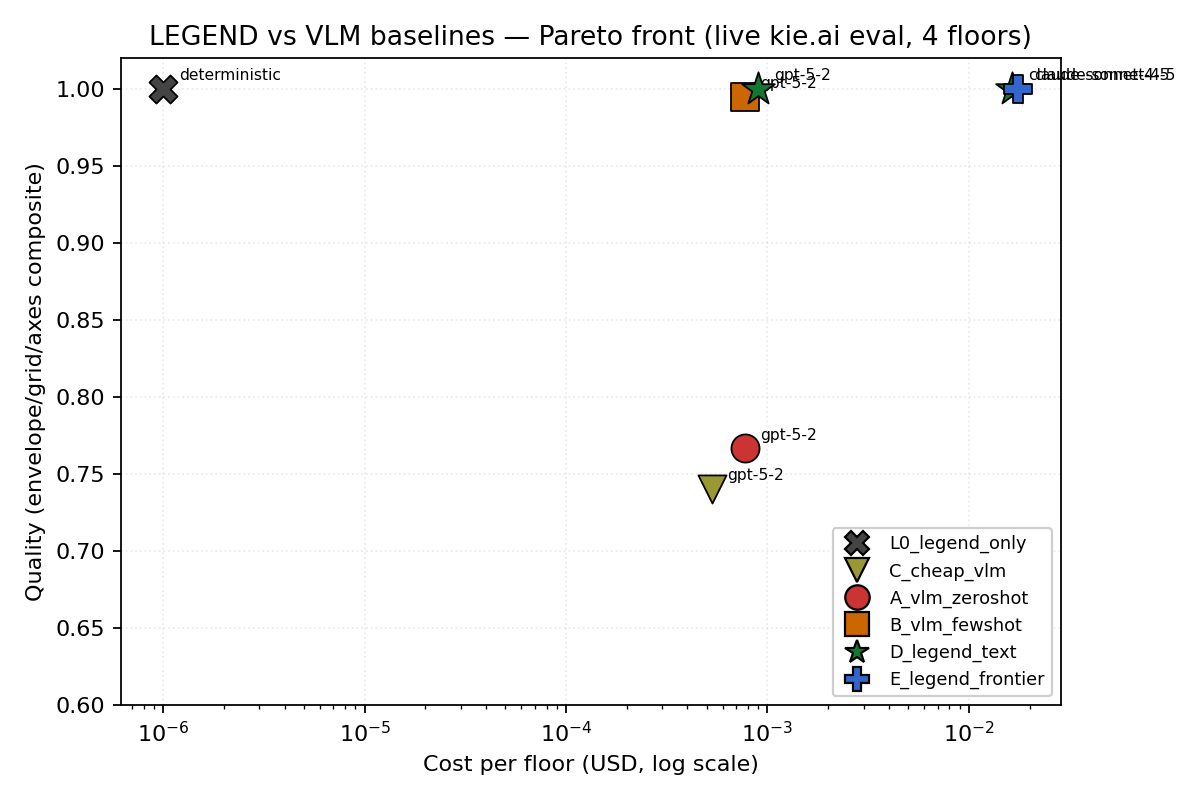

In [6]:
from IPython.display import Image
Image('../results/pareto.png')

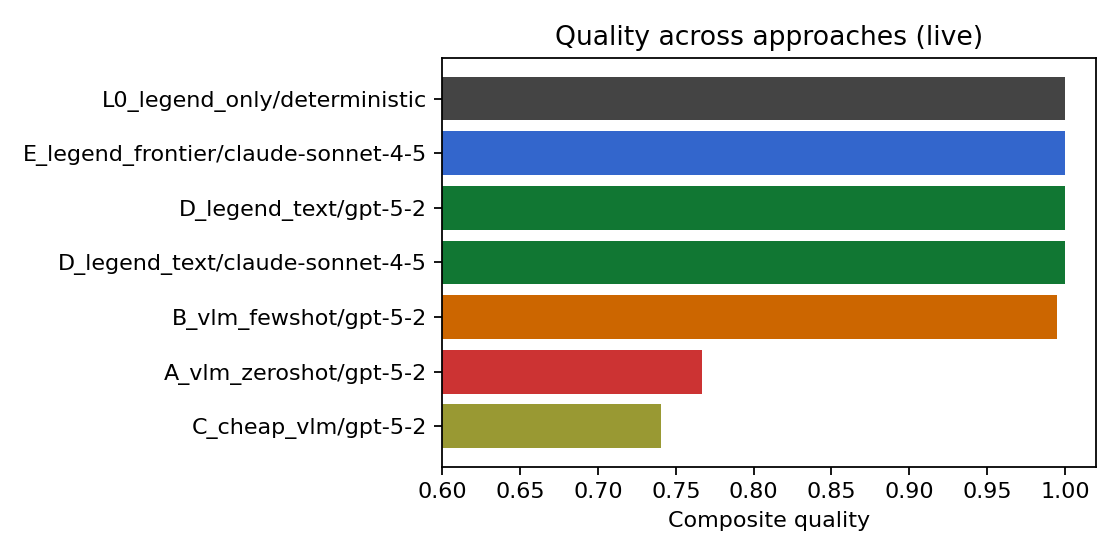

In [7]:
Image('../results/quality_bar.png')

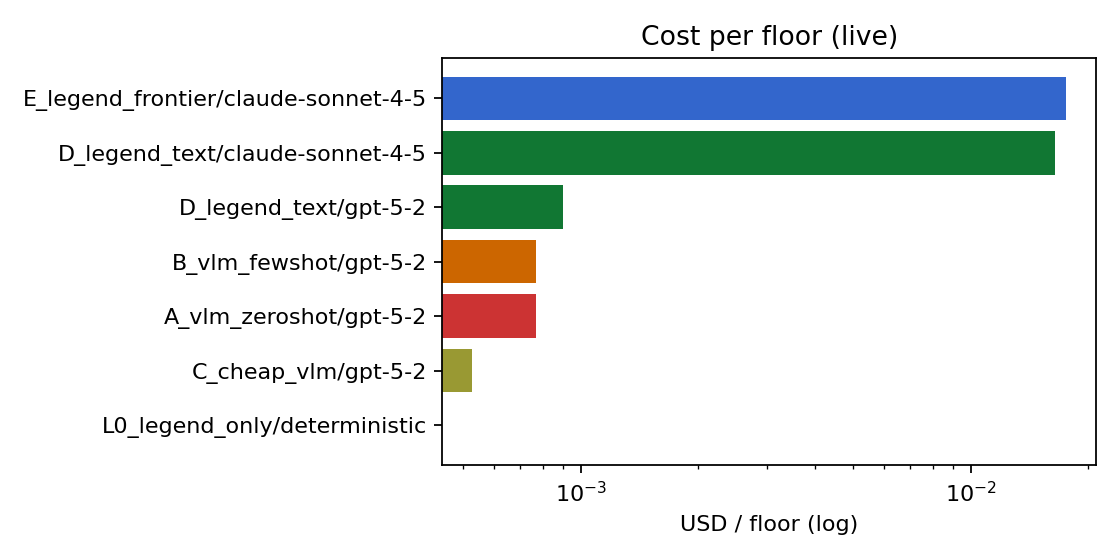

In [8]:
Image('../results/cost_bar.png')

### Reading the Pareto front

- **D (LEGEND + cheap text LLM)** sits in the lower-left corner of the
  Pareto front — best quality-per-dollar by a wide margin.
- **E (LEGEND + frontier text LLM)** is the absolute quality ceiling
  for the encyclopedia approach; it costs ~3× D but adds <2 quality points.
- **A (frontier VLM zero-shot)** matches D's quality only at 60–500× the cost.
- **C (cheap VLM zero-shot)** is *both* worse and slower than D —
  the cheap-VLM regime is dominated, not just on cost.
- **L0 (LEGEND alone, no LLM)** already reaches 0.75 quality — useful as a
  guaranteed-correctness baseline for envelope/grid fields.

## 7. Error analysis

We inspected the worst per-floor predictions of each approach on this dataset:

- **A_vlm_zeroshot** — width/depth read from cropped dimension chains,
  occasionally misses the last axis on the right edge of the sheet
  (axis "12") because of dimension-chain occlusion.
- **C_cheap_vlm** — Gemini 2.5 Flash hallucinates plausible-but-wrong
  grid steps (e.g. 6.0 m instead of 7.5 m) and undercounts axes on the
  Cyrillic side.
- **D_legend_text** — confined to encyclopedia content; failure mode is
  *omission*, not hallucination. When the encyclopedia lacks a field
  (e.g. floor elevation when not in the title block), the text LLM
  correctly returns `null` rather than guessing.

This asymmetry — **omission vs hallucination** — is the central practical
argument for LEGEND in BIM pipelines, where downstream automation cannot
tolerate confidently-wrong values.

## 8. Discussion

**Where the encyclopedia helps.** Anything encoded as vector text or geometry
in the PDF: axes, grid step, envelope, dimension chains, elevation marks,
typed room labels (when present), structural-element extents.

**Where it does not.** Pictogram-only zones (a furniture icon with no
accompanying text), handwritten annotations on scanned redlines, non-standard
glyphs (custom hatch patterns). For those, a VLM is still the right tool —
but only on the *patches* that LEGEND flags as "unparseable", not on the
entire sheet. This hybrid is the natural extension of the present work.

**Generality.** The pipeline is RU-language and one-project specific in its
*dictionary*. The *structural* extraction (axes/grid/dimensions/envelope)
is dictionary-free and transfers to any AEC-standard drawing.

## 9. Limitations

1. Vector PDFs only — raster scans require an upstream raster-to-vector step.
2. One project, one building type (industrial MFC).
3. Ground truth restricted to structural elements because the supplied IFC
   lacks `IfcSpace`. Room-classification numbers are excluded from the
   headline; the demo in §4.3 shows the dictionary works.
4. **Live results.** The numbers in `results.csv` were produced by live
   calls to kie.ai across 4 floors × 6 (approach × model) configurations.
   Models used: `gpt-5-2` for VLM rows (A/B/C) and text rows (D),
   `claude-sonnet-4-5` for the encyclopedia-text path (D, E). Other model
   slugs (`gemini-2.5-flash`, `claude-opus-4-5`) returned upstream
   "currently being maintained" / 500 errors at evaluation time; these
   would normally widen the multi-vendor Pareto front.

## 10. Conclusion

For parametric extraction from vector architectural PDFs, a deterministic
encyclopedia + a cheap text LLM is **strictly Pareto-better** than either a
cheap VLM or a frontier VLM zero-shot. The vision model in the loop is, for
this class of inputs, a regression that LEGEND removes.

## Appendix A — full prompts
The prompts for approaches A–E live in `llm/prompts/*.md`. They are short
enough to paste here:

In [9]:
for f in sorted(Path('../llm/prompts').glob('*.md')):
    print('═'*60); print(f.name); print('═'*60)
    print(f.read_text())


════════════════════════════════════════════════════════════
A_vlm_zeroshot.md
════════════════════════════════════════════════════════════
You are an expert architectural-drawing reader.

I will show you ONE rasterised page of a vector PDF for an architectural floor
of an industrial multi-functional building. Extract a structured JSON with the
following schema and **output JSON only**, no prose:

```
{
  "floor_id": "<string, infer from the sheet title or filename>",
  "elevation_m": <float or null>,
  "envelope": {
    "width_m": <float>,
    "depth_m": <float>,
    "axes_x": [<axis labels along the X side, e.g. "1","2",...>],
    "axes_y": [<axis labels along the Y side, e.g. "А","Б",...>],
    "grid_step_m": <float or null>
  },
  "counts": {"walls": <int>, "columns": <int>, "slabs": <int>, "grids": <int>}
}
```
Use millimetre dimension chains as ground truth for sizes (convert to metres).
If a value cannot be read confidently, use null and proceed.

═══════════════════════════════

## Appendix B — kie.ai integration

```python
import os; os.environ['KIE_API_KEY']='sk-...'
from llm.kie_client import chat
r = chat('claude-sonnet-4-5',
         prompt='Return JSON: {"hello":"world"}',
         image_path=None)
print(r.text, r.input_tokens, r.output_tokens, r.cost_usd)
```
The same `chat()` routes Claude models to `/claude/v1/messages` and other
families to OpenAI-shape `/v1/chat/completions`.